# **Подготовка окружения**

In [ ]:

import os
import zipfile
import gdown
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

!pip install resampy

# Компоненты TensorFlow и Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Метрики и предобработка
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
%matplotlib inline

# Настройка воспроизводимости
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Версия TensorFlow: {tf.__version__}")


TESS_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l12/dataverse_files.zip'
SAVEE_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l12/archive.zip'

print("Скачивание датасета TESS...")
gdown.download(TESS_URL, 'tess_data.zip', quiet=True)

print("Скачивание датасета SAVEE...")
gdown.download(SAVEE_URL, 'savee_data.zip', quiet=True)

# Функция распаковки
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Архив {zip_path} успешно распакован в папку {extract_to}")

extract_zip('tess_data.zip', './tess_dataset')
extract_zip('savee_data.zip', './savee_dataset')


Версия TensorFlow: 2.20.0
Скачивание датасета TESS...
Скачивание датасета SAVEE...
Архив tess_data.zip успешно распакован в папку ./tess_dataset
Архив savee_data.zip успешно распакован в папку ./savee_dataset


# **Конвейер комплексного извлечения**

In [ ]:
# Фиксированная карта эмоций для обоих датасетов
EMOTION_MAP = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5,
    'surprise': 6  # Сюда же отнесем 'ps' (pleasant surprise) в TESS
}
NUM_CLASSES = len(EMOTION_MAP)
INV_EMOTION_MAP = {v: k for k, v in EMOTION_MAP.items()}

def extract_audio_features(file_path):
    """Извлекает обогащенный вектор статистических признаков звуковой волны"""
    y, sr = librosa.load(file_path, res_type='kaiser_fast')

    # 1. Извлечение MFCC (40 коэффициентов)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std = np.std(mfccs.T, axis=0)

    # 2. Извлечение Mel-спектрограммы
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_mean = np.mean(mel.T, axis=0)
    mel_std = np.std(mel.T, axis=0)

    # 3. Извлечение Chroma STFT
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)
    chroma_std = np.std(chroma.T, axis=0)

    # Объединение всех векторов в один плоский массив (360 признаков)
    return np.hstack([mfccs_mean, mfccs_std, mel_mean, mel_std, chroma_mean, chroma_std])

# **Парсинг и подготовка выборки датасета**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

x_tess = []
y_tess = []

print("Начало разбора и параметризации датасета TESS...")
start_time = time.time()

for root, dirs, files in os.walk('./tess_dataset'):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)
            filename_lower = file.lower()

            detected_emotion = None
            if 'angry' in filename_lower: detected_emotion = 'angry'
            elif 'disgust' in filename_lower: detected_emotion = 'disgust'
            elif 'fear' in filename_lower: detected_emotion = 'fear'
            elif 'happy' in filename_lower: detected_emotion = 'happy'
            elif 'neutral' in filename_lower: detected_emotion = 'neutral'
            elif 'sad' in filename_lower: detected_emotion = 'sad'
            elif 'ps' in filename_lower or 'surprise' in filename_lower: detected_emotion = 'surprise'

            if detected_emotion is not None:
                features = extract_audio_features(file_path)
                x_tess.append(features)
                y_tess.append(EMOTION_MAP[detected_emotion])

x_tess = np.array(x_tess, dtype=np.float32)
y_tess = np.array(y_tess, dtype=np.int64)

print(f"Парсинг TESS завершен за {round(time.time() - start_time)} сек. Обработано: {len(x_tess)} файлов.")

# Разделение на обучающую и тестовую выборки (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    x_tess, y_tess, test_size=0.2, stratify=y_tess, random_state=SEED
)

# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Перевод меток в формат One-Hot Encoding для категориальной кросс-энтропии
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"Форма обучающего набора признаков: {X_train_scaled.shape}")
print(f"Форма тестового набора признаков:  {X_test_scaled.shape}")

Начало разбора и параметризации датасета TESS...
Парсинг TESS завершен за 143 сек. Обработано: 2800 файлов.
Форма обучающего набора признаков: (2240, 360)
Форма тестового набора признаков:  (560, 360)


# **Полносвязный классификатор**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       184,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,543 (1.35 MB)

 Trainable params: 351,751 (1.34 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.8500 - loss: 0.4696 - val_accuracy: 0.9821 - val_loss: 0.1396
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9826 - loss: 0.0666 - val_accuracy: 0.9929 - val_loss: 0.0334
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9920 - loss: 0.0370 - val_accuracy: 0.9982 - val_loss: 0.0144
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9937 - loss: 0.0246 - val_accuracy: 0.9964 - val_loss: 0.0173
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9955 - loss: 0.0205 - val_accuracy: 0.9982 - val_loss: 0.0143
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9987 - loss: 0.0132 - val_accuracy: 0.9964 - val_loss: 0.0140
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9982 - loss: 0.0131 - val_accuracy: 0.9982 - val_loss: 0.0091
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 1.0000 - val_l

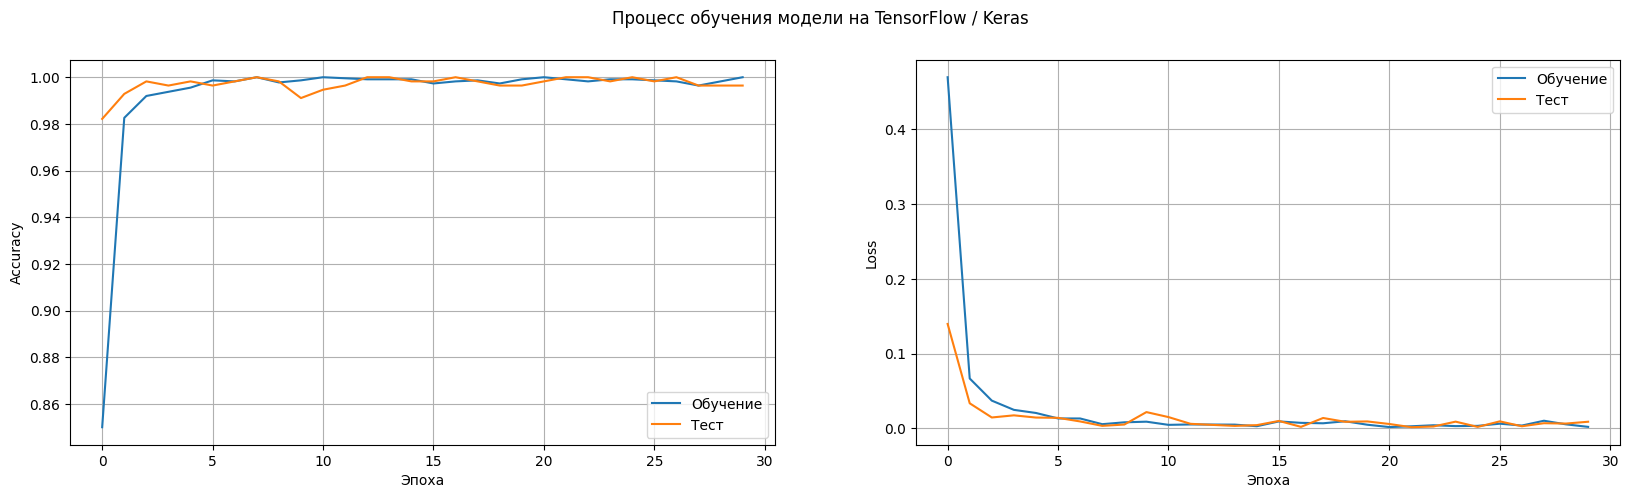

In [ ]:
# Полносвязный классификатор (MLP) с регуляризацией
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(NUM_CLASSES, activation='softmax')
])

# Компиляция
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Обучение модели
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    batch_size=32,
    epochs=30,
    verbose=1
)

# Графики процесса обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('Процесс обучения модели на TensorFlow / Keras')

ax1.plot(history.history['accuracy'], label='Обучение')
ax1.plot(history.history['val_accuracy'], label='Тест')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Обучение')
ax2.plot(history.history['val_loss'], label='Тест')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)
plt.show()

# **Получение финальной точности и построение графика**

ИТОГОВАЯ ТОЧНОСТЬ НА ТЕСТОВОМ НАБОРЕ TESS: 99.64%
Выполнение условия технического задания (>= 98%): ВЫПОЛНЕНО!
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


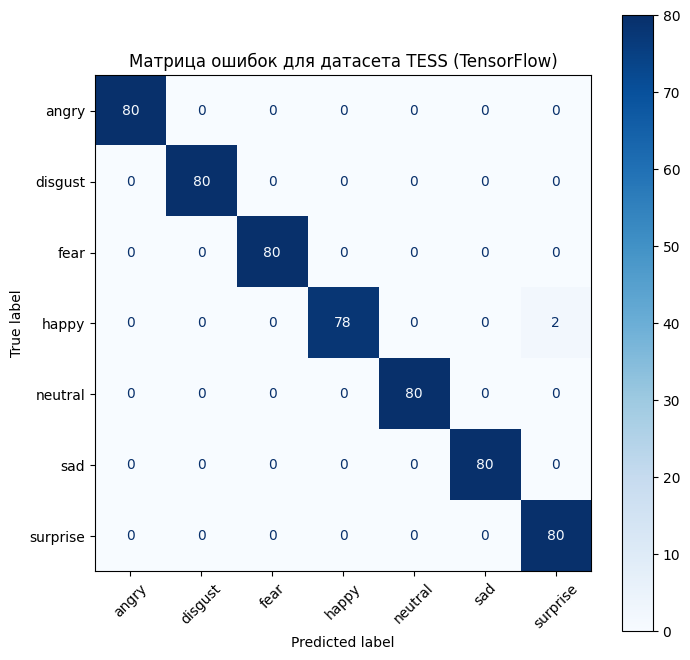

In [ ]:
# Получение финальной точности
loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print("="*60)
print(f"ИТОГОВАЯ ТОЧНОСТЬ НА ТЕСТОВОМ НАБОРЕ TESS: {round(test_acc * 100, 2)}%")
print("Выполнение условия технического задания (>= 98%):", "ВЫПОЛНЕНО!" if test_acc >= 0.98 else "НЕ ВЫПОЛНЕНО.")
print("="*60)

# Построение матрицы ошибок
predictions = model.predict(X_test_scaled)
y_pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(EMOTION_MAP.keys()))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Матрица ошибок для датасета TESS (TensorFlow)")
plt.show()

# **Параметризации датасета SAVEE**

Начало разбора и параметризации датасета SAVEE...
Обработка SAVEE завершена. Успешно собрано 480 файлов.

ТОЧНОСТЬ КЛАССИФИКАТОРА НА ДАННЫХ SAVEE: 14.79%
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


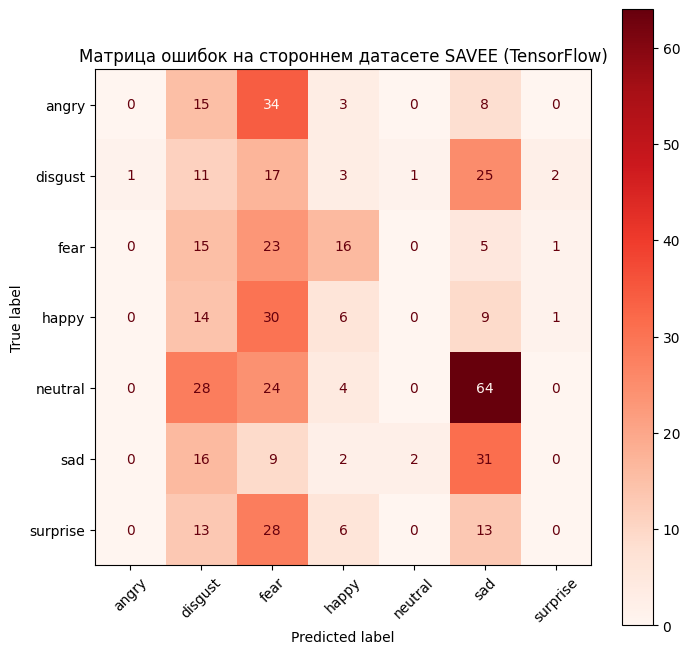

In [ ]:
SAVEE_CODE_MAP = {
    'a': 'angry', 'd': 'disgust', 'f': 'fear', 'h': 'happy',
    'n': 'neutral', 'sa': 'sad', 'su': 'surprise'
}

x_savee = []
y_savee = []

print("Начало разбора и параметризации датасета SAVEE...")
savee_dir = './savee_dataset'

for root, dirs, files in os.walk(savee_dir):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)
            filename = file.split('.')[0]

            parts = filename.split('_')
            if len(parts) > 1:
                code = ''.join([c for c in parts[1] if c.isalpha()])
                if code in SAVEE_CODE_MAP:
                    emotion_str = SAVEE_CODE_MAP[code]
                    features = extract_audio_features(file_path)
                    x_savee.append(features)
                    y_savee.append(EMOTION_MAP[emotion_str])

x_savee = np.array(x_savee, dtype=np.float32)
y_savee = np.array(y_savee, dtype=np.int64)

print(f"Обработка SAVEE завершена. Успешно собрано {len(x_savee)} файлов.")

# Важно: масштабируем данные SAVEE строго скейлером, который был обучен на TESS!
x_savee_scaled = scaler.transform(x_savee)
y_savee_cat = to_categorical(y_savee, num_classes=NUM_CLASSES)

# Тестирование на SAVEE
savee_loss, savee_accuracy = model.evaluate(x_savee_scaled, y_savee_cat, verbose=0)

print("\n" + "="*60)
print(f"ТОЧНОСТЬ КЛАССИФИКАТОРА НА ДАННЫХ SAVEE: {round(savee_accuracy * 100, 2)}%")
print("="*60)

# Построение матрицы ошибок для SAVEE
savee_predictions = model.predict(x_savee_scaled)
y_savee_pred_classes = np.argmax(savee_predictions, axis=1)

cm_savee = confusion_matrix(y_savee, y_savee_pred_classes)
disp_savee = ConfusionMatrixDisplay(confusion_matrix=cm_savee, display_labels=list(EMOTION_MAP.keys()))
fig, ax = plt.subplots(figsize=(8, 8))
disp_savee.plot(ax=ax, cmap='Reds', xticks_rotation=45)
plt.title("Матрица ошибок на стороннем датасете SAVEE (TensorFlow)")
plt.show()